<a href="https://colab.research.google.com/github/sakarla/Machine-Learning-for-Architecs/blob/main/week%203_DataCollection/Code/week3_datacollection_api_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data collection with API**

In this notebook, you will learn how to collect data from the Internet using an API.

We will work with **Google's Maps APIs** to collect **street view images**, **satellite images** and **3D models** of any place on Earth.

**What is API?**

An API (Application Programming Interface) is like a bridge that allows two different software applications to communicate with each other.

**Why Use an API?**

APIs are useful because they allow you to access the functionality or data of other software systems in a structured way. This means you can leverage powerful services and data without having to build everything from scratch.

To do this you need to learn how to get the API key.

# **Part 0 — Set up your Google API key (do this once)**

Google's map services need a **key** that identifies who is asking for the data. Getting one takes about 10 minutes.
Follow the screenshots step by step. You need a Google account and a credit card (Google gives free monthly usage that covers everything we do in this course, but it still asks for a card).

## Step 1 — Open the Google Cloud Console

Go to **https://console.cloud.google.com** and sign in with your Google account.

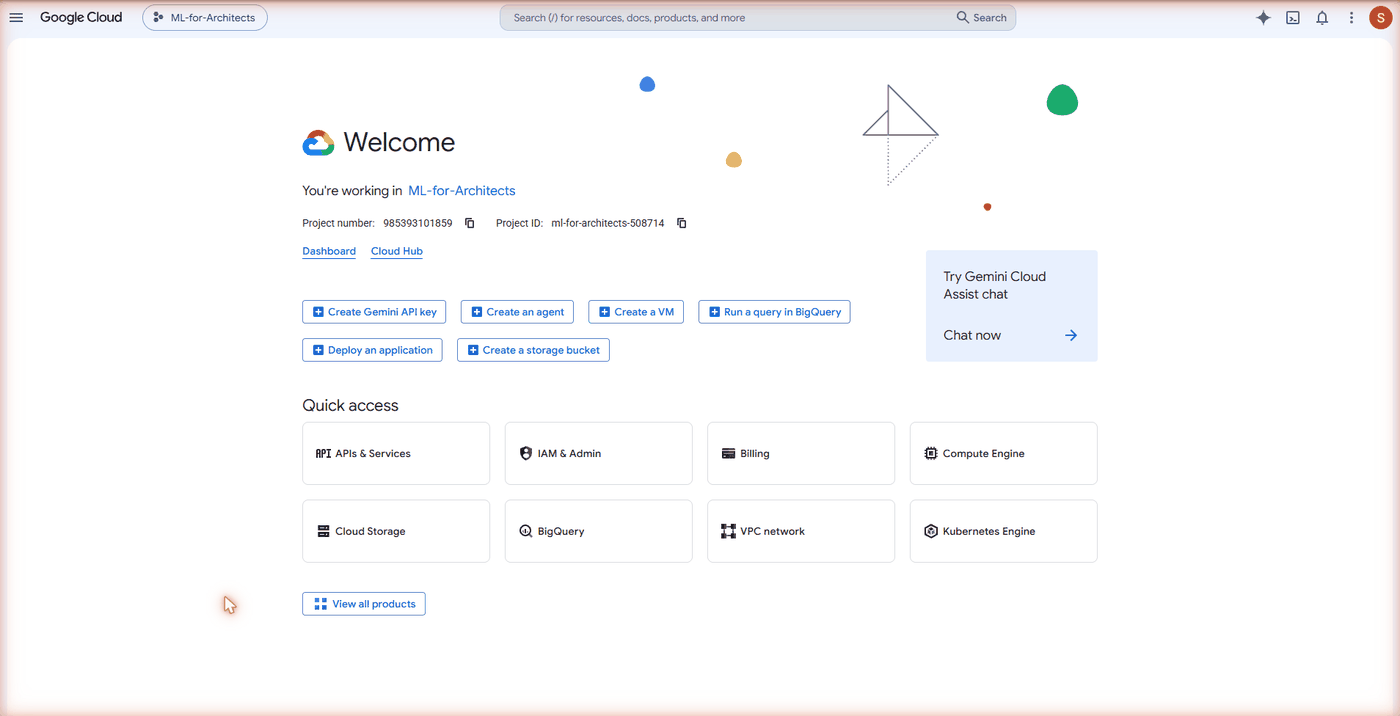

## Step 2 — Create a project

Click the **project name** at the top of the page (it may say "Select a project"), then click **New project**.

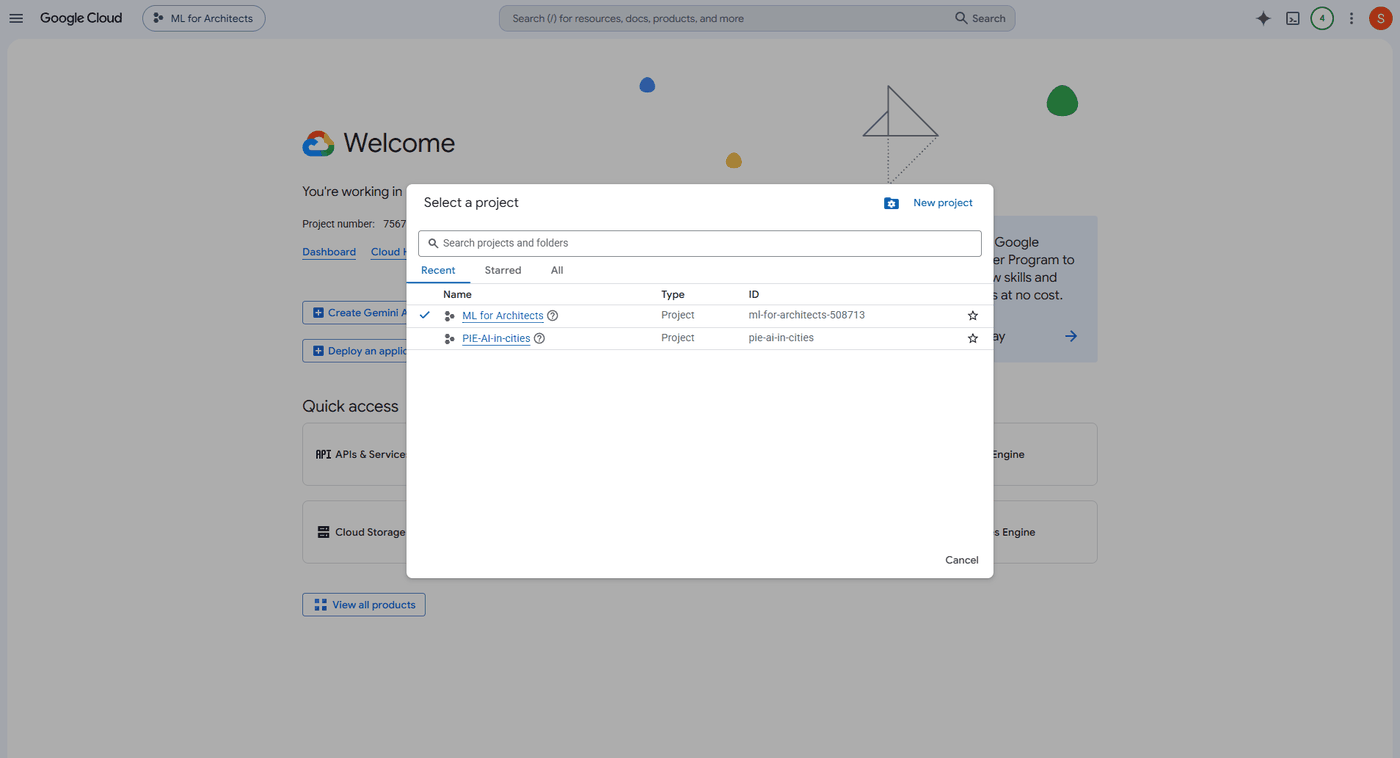

Give it a name such as `ML-for-Architects` and click **Create**.

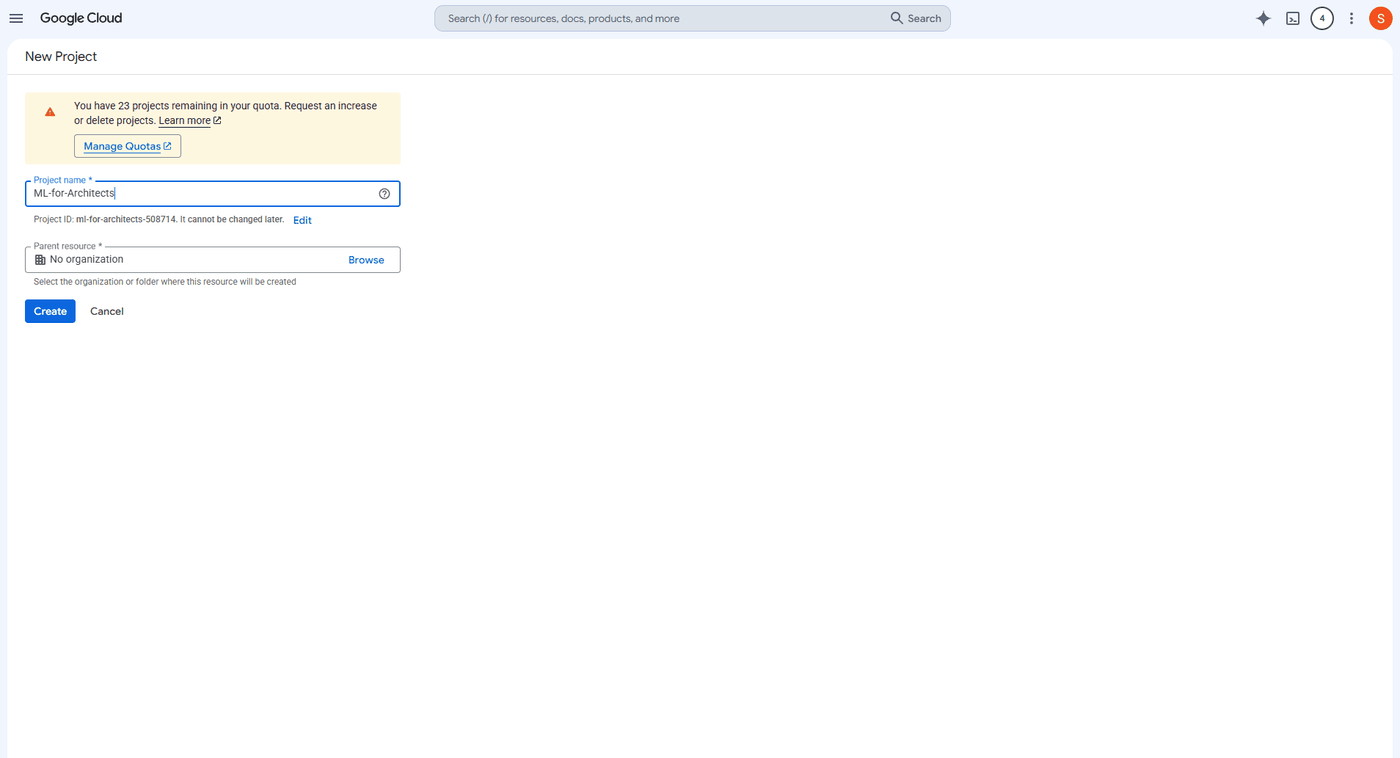

Wait for the notification, then click **Select project** so the new project is active (its name shows at the top).

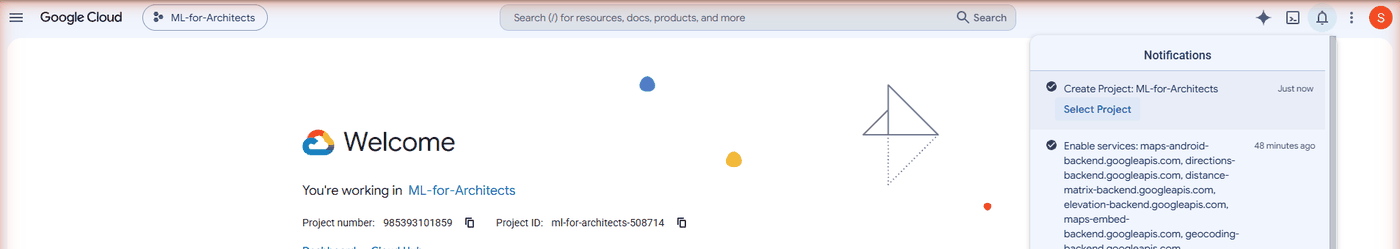

## Step 3 — Enable the Street View Static API (this also creates your key)

Open the menu **☰ → APIs & Services → Library**.

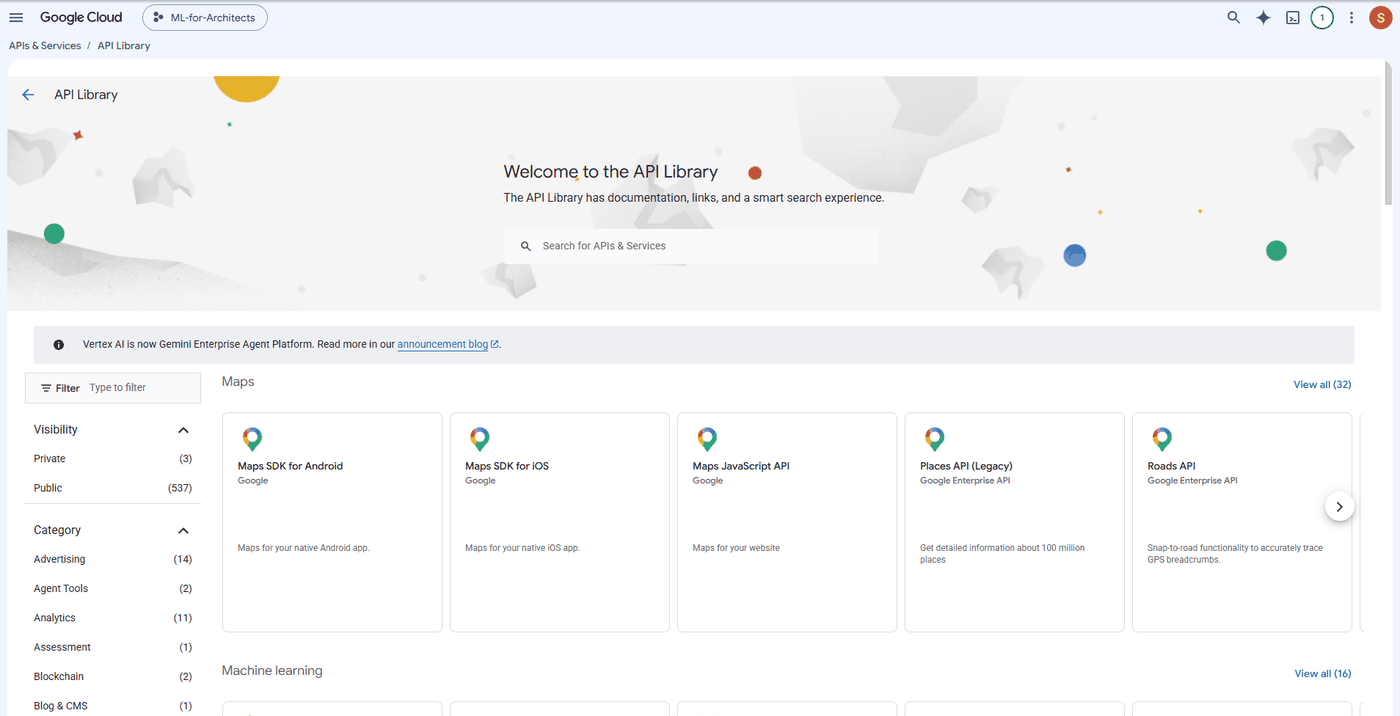

Search for **Street View Static API** and click the result.

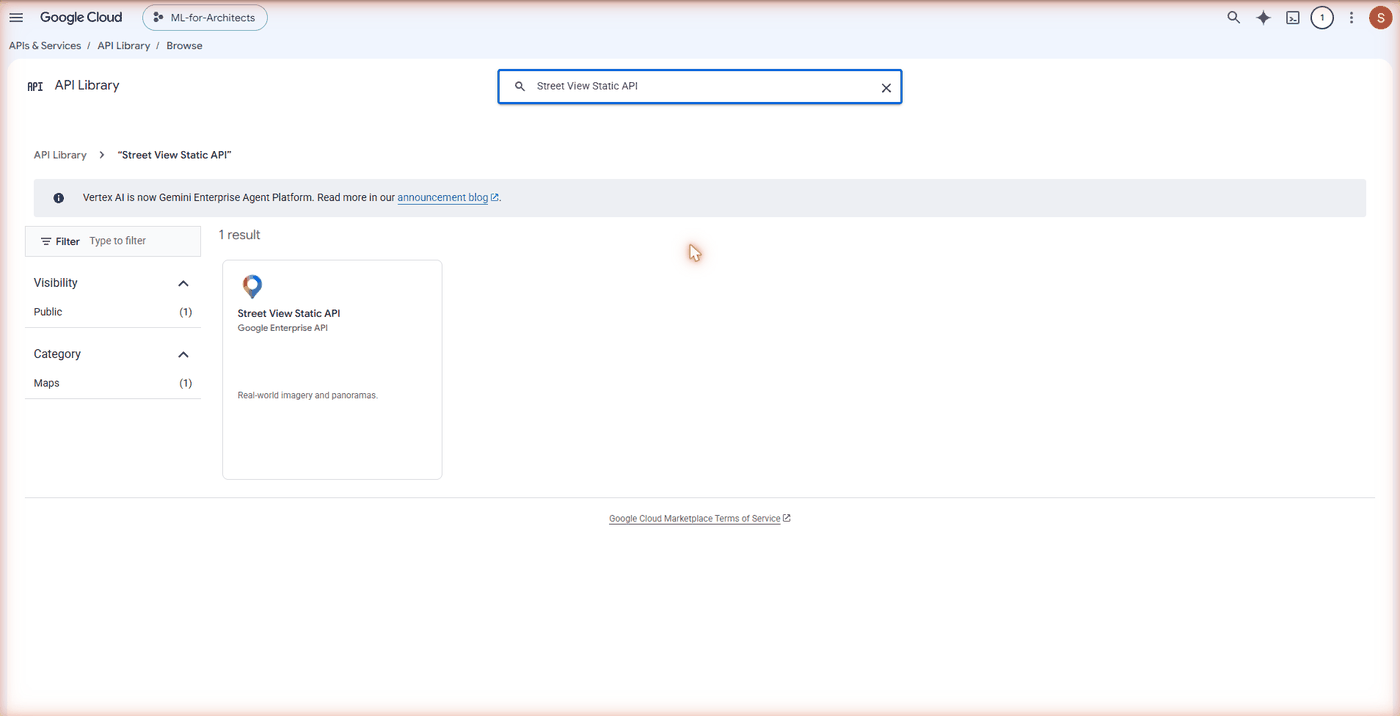

Click **Enable**.

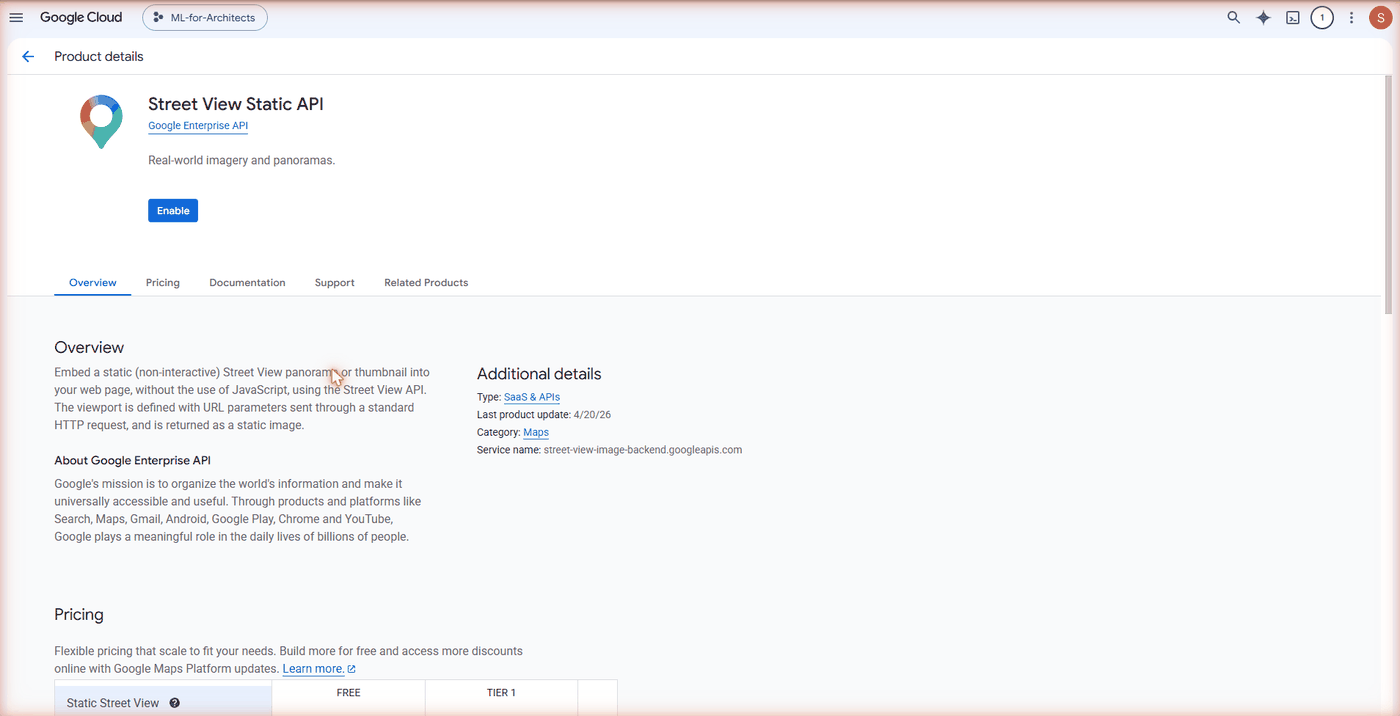

Google now opens a short **"Get started on Google Maps Platform"** wizard. If your account has no billing account yet, it asks you to add one (a card is required, but the free monthly usage covers this course). At the end it shows **your API key**. Click the copy icon and keep the key somewhere safe.

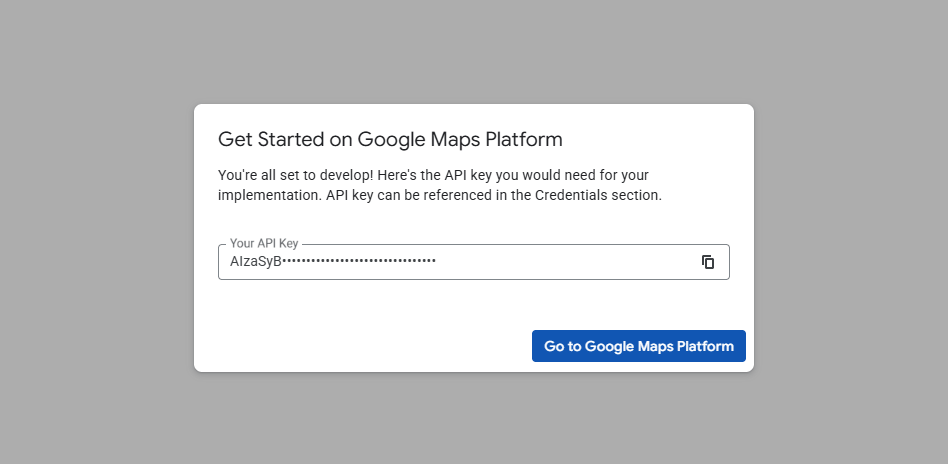

## Step 4 — Enable the two other APIs

Go back to **☰ → APIs & Services → Library** and repeat the search-and-enable of Step 3 for:
* **Maps Static API** (satellite images)
* **Map Tiles API** (3D models)

Each one takes a few seconds. You do not need a new key: the key from Step 3 works for all three.

## Step 5 — Where to find your key again

Open **☰ → APIs & Services → Credentials**. Your key is listed under **API Keys**; click **Show key** to see it.

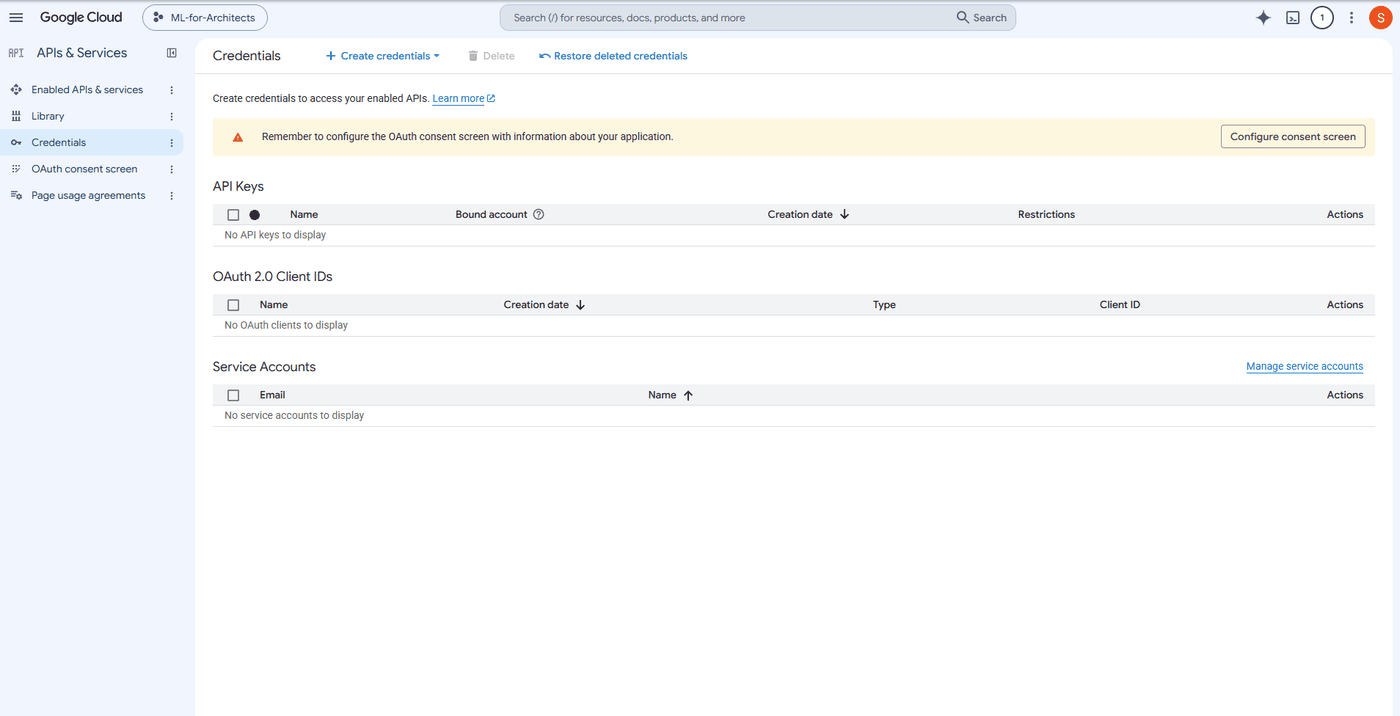

If the list is empty, create one: click **+ Create credentials → API key**.

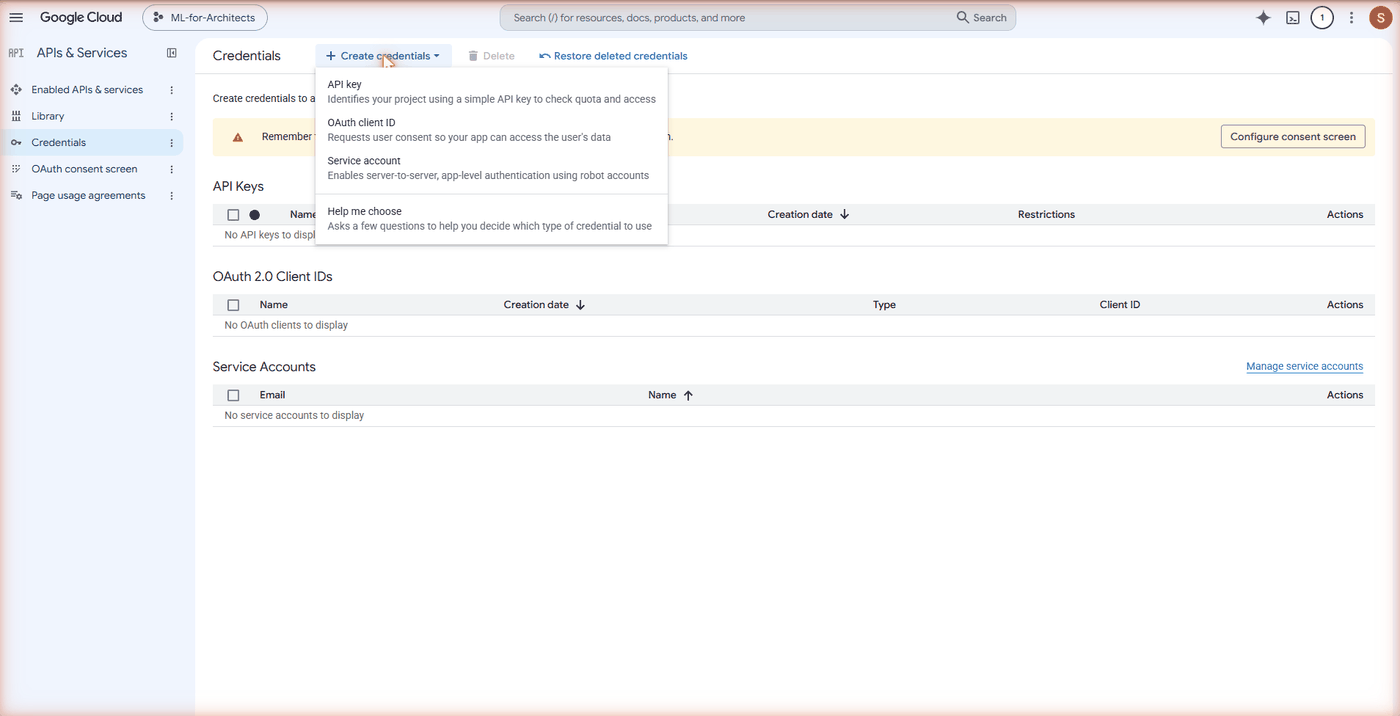

Give it a name, under *Select API restrictions* tick the three APIs, and click **Create**.

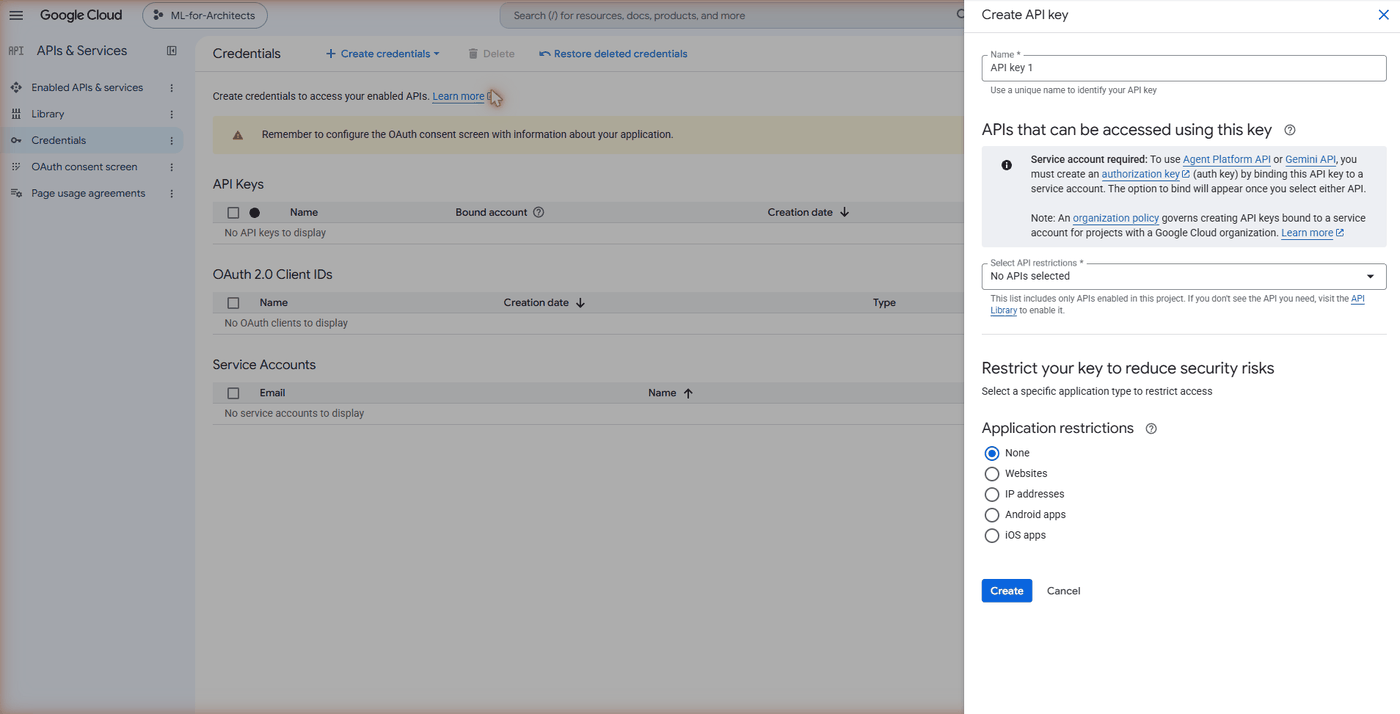

## Step 6 — Paste the key into the notebook

Run the next cell after pasting your key between the quotes. **Treat the key like a password**: do not share it and do not upload a notebook that contains it to GitHub.

## If something goes wrong

| Message you see | Cause | Fix |
|---|---|---|
| `This API project is not authorized to use this API` / `REQUEST_DENIED` | the API is not enabled on your project | Step 4 (check you are in the right project) |
| `You must enable Billing on the Google Cloud Project` | no billing account linked | Step 3 |
| `The provided API key is invalid` / `API key not valid` | typo, extra spaces, or key from another project | copy the key again from Credentials |
| `403` when downloading 3D tiles | Map Tiles API not enabled | Step 4 |
| it worked a minute ago and now fails | changes take a few minutes to apply | wait 2–5 minutes and retry |

This is what the most common error looks like (here the Maps Static API was not enabled yet):
```
The Google Maps Platform server rejected your request. This API is not activated on your API project.
You may need to enable this API in the Google Cloud Console: https://console.cloud.google.com/apis/library?filter=category:maps
```

In [ ]:

# Paste your API key between the quotes (keep it private: never share it or upload it to GitHub)
api_key = ""

*(Colab only, optional)* Run the next cell to save the downloaded files to your Google Drive instead of the temporary Colab disk.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab Notebooks/ML_for_Architects

# **Part 1 — Street view images**

The **Street View Static API** returns a photo taken from the street at a location. We ask for it with a URL that contains the location, the image size, the direction we look at (`heading`, 0 = north, 90 = east), the tilt (`pitch`) and the field of view (`fov`).

Let's test your key with one image.

In [ ]:
import requests
from PIL import Image
from io import BytesIO

def download_streetview_image(api_key, location, size="600x300", heading=0, pitch=0, fov=90):
    streetview_url = "https://maps.googleapis.com/maps/api/streetview"
    params = {
        "size": size,
        "location": location,
        "heading": heading,
        "pitch": pitch,
        "fov": fov,
        "key": api_key
    }

    response = requests.get(streetview_url, params=params)
    if response.status_code == 200:
        img = Image.open(BytesIO(response.content))
        img.save('streetview_image.jpg')
        print("Image downloaded and saved as 'streetview_image.jpg'")
        display(img)
    else:
        print(f"Error: {response.status_code}, {response.text}")

# Replace with your own values

location = "40.689247,-74.044502"  # Latitude, Longitude for the Statue of Liberty

download_streetview_image(api_key, location)

# **Collecting Multiple Satellite Images and street view images**

To collect more than one satellite or street view image, we first need to generate a list of geographic coordinates that define the image collection points.


**Creating a Regular Grid of Coordinates**

Creating a "regular" grid can be tricky due to the nature of geographic coordinate systems. Latitude and longitude (EPSG:4326) define positions on the Earth's surface using degrees—not meters—so spacing that appears regular in degrees is not truly uniform in real-world distance.

To generate a grid that is uniformly spaced in meters, we must:

*  **Convert geographic coordinates** to a projected coordinate system that supports metric units.

*  **Generate points at regular intervals (e.g., every 50 meters)** within the bounding box of the area of interest.

*  **Convert those projected coordinates** back to latitude and longitude for use with APIs like Google Street View.

Note: As a simple approximation, we may use the Haversine formula to calculate distances between lat/lon points. However, for higher accuracy or large areas, using a proper projection (like UTM or Web Mercator) is recommended.

**Working with Google Maps Bounding Box**

In this example, we will extract the bounding box (north, south, east, and west extents) of a specific area using Google Maps. Google Maps uses the Web Mercator projection (EPSG:3857 or EPSG:900913), which is suitable for visual mapping and distance approximations on the web.

In [ ]:
!pip install shapely

import shapely.geometry
import pyproj

# --- Define Coordinate Reference Systems ---
# EPSG:4326 = Latitude/Longitude (degrees)
# EPSG:3857 = Web Mercator (meters), used for metric distance grid
# Set up transformers, EPSG:3857 is metric, same as EPSG:900913
to_proxy_transformer = pyproj.Transformer.from_crs('epsg:4326', 'epsg:3857')
to_original_transformer = pyproj.Transformer.from_crs('epsg:3857', 'epsg:4326')

# Create corners of rectangle to be transformed to a grid
sw = shapely.geometry.Point((-81.434734, 28.466189))
ne = shapely.geometry.Point((-81.412675, 28.484533))

stepsize = 1000 # 1 km (1000 m) grid step size

# Project corners to target projection
transformed_sw = to_proxy_transformer.transform(sw.x, sw.y) # Transform NW point to 3857
transformed_ne = to_proxy_transformer.transform(ne.x, ne.y) # .. same for SE

# Iterate over 2D area
gridpoints = []
x = transformed_sw[0]
while x < transformed_ne[0]:
    y = transformed_sw[1]
    while y < transformed_ne[1]:
        p = shapely.geometry.Point(to_original_transformer.transform(x, y))
        gridpoints.append(p)
        y += stepsize
    x += stepsize

with open('testout.csv', 'w') as of:
    of.write('lat;lon\n')
    for p in gridpoints:
        of.write('{:f};{:f}\n'.format(p.y, p.x))

In [ ]:
import pandas as pd

# Load and inspect the CSV file

##################################################
file_path = "testout.csv"  # Replace with the correct path to your CSV file

##################################################

# Read the CSV file without specifying a delimiter
coords= pd.read_csv(file_path)

  # Ensure the 'lat;lon' column is treated as strings
coords['lat;lon'] = coords['lat;lon'].astype(str)

    # Transform the coordinates into comma-separated strings
coords['lat;lon'] = coords['lat;lon'].str.replace(';', ',')

locations= coords['lat;lon'].tolist()

# **Collecting several streetview images**

In [ ]:
import os
import requests
from PIL import Image
from io import BytesIO

def download_streetview_image(api_key, location, folder_name, size="600x300", heading=0, pitch=0, fov=90):

    # Create the folder if it doesn't exist
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    streetview_url = "https://maps.googleapis.com/maps/api/streetview"
    params = {
        "size": size,
        "location": location,
        "heading": heading,
        "pitch": pitch,
        "fov": fov,
        "key": api_key
    }

    response = requests.get(streetview_url, params=params)
    if response.status_code == 200:
        img = Image.open(BytesIO(response.content))
        if img.mode == 'P':  # Check if the image is palette-based
            img = img.convert('RGB')  # Convert to RGB mode
        location_str = location.replace(',', '_').replace(' ', '')  # Format location string for filename
        img.save(os.path.join(folder_name, f'{location_str}.jpg'))
        print(f"Image downloaded and saved as '{os.path.join(folder_name, location_str)}.jpg'")
    else:
        print(f"Error: {response.status_code}, {response.text}")

# Replace with your own values

folder_name = "streetview_images"  # Folder to save images

for location in locations:
    download_streetview_image(api_key, location, folder_name)

# **Part 2 — Satellite images**

The **Maps Static API** returns a map image centred on a location. With `maptype="satellite"` we get aerial imagery. `zoom` goes from 0 (whole Earth) to about 20 (a single building); 18 is a good value for a block. You enabled this API in Part 0, so the same key works.

In [ ]:
import os
import requests
from PIL import Image
from io import BytesIO

def download_satellite_image(api_key, location, folder_name, zoom=18, size="600x600", maptype="satellite"):
    # Create the folder if it doesn't exist
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    maps_url = "https://maps.googleapis.com/maps/api/staticmap"
    params = {
        "center": location,
        "zoom": zoom,
        "size": size,
        "maptype": maptype,
        "key": api_key
    }

    response = requests.get(maps_url, params=params)
    if response.status_code == 200:
        img = Image.open(BytesIO(response.content))
        if img.mode == 'P':  # Check if the image is palette-based
            img = img.convert('RGB')  # Convert to RGB mode
        location_str = location.replace(',', '_').replace(' ', '')  # Format location string for filename
        img.save(os.path.join(folder_name, f'{location_str}.jpg'))
        print(f"Image downloaded and saved as '{os.path.join(folder_name, location_str)}.jpg'")
    else:
        print(f"Error: {response.status_code}, {response.text}")

# Replace with your own values

folder_name = "satellite_images"  # Folder to save images

for location in locations:
    download_satellite_image(api_key, location, folder_name)

# **Part 3 — 3D models from Google Maps**

The 3D cities you see in Google Maps / Google Earth are available through the **Map Tiles API** as **Photorealistic 3D Tiles**: the world is cut into a tree of small textured meshes (`.glb` files), from coarse (whole city) to fine (single facades).

We will:
1. ask Google for the tile tree,
2. keep only the tiles around a location, at the level of detail we want,
3. download them, look at them inside the notebook, and export one model for Rhino or Blender.

**Good to know**
* Same key as before; the **Map Tiles API** must be enabled (Part 0, Step 4).
* Google counts one *root tile request* each time we ask for the tile tree. The tiles below it are free, so we ask for the tree once per download.
* The data is © Google and its partners. Keep the credits shown in the viewer if you present it, and do not redistribute the raw tiles.

**How to get the coordinates of a place:** right-click on Google Maps; the first line of the menu is `latitude, longitude`, click it to copy.

In [ ]:
import os, math, requests
import numpy as np

TILES_URL = "https://tile.googleapis.com"
DETAIL = {"low": 16, "medium": 8, "high": 4}   # max "geometric error" in metres: smaller = finer tiles, more files


def latlon_to_ecef(lat, lon, h=0.0):
    """Latitude/longitude in degrees -> Earth-centred XYZ in metres (the frame Google's tiles use)."""
    a, f = 6378137.0, 1 / 298.257223563
    e2 = f * (2 - f)
    lat, lon = math.radians(lat), math.radians(lon)
    N = a / math.sqrt(1 - e2 * math.sin(lat) ** 2)
    return np.array([(N + h) * math.cos(lat) * math.cos(lon),
                     (N + h) * math.cos(lat) * math.sin(lon),
                     (N * (1 - e2) + h) * math.sin(lat)])


def horizontal_distance(box, p):
    """Horizontal distance (metres) from point p to a tile's bounding box (centre + 3 half-axes).
    Height is ignored, so tall buildings above the point are kept."""
    b = np.asarray(box, float)
    centre, axes = b[0:3], (b[3:6], b[6:9], b[9:12])
    closest = centre.copy()
    for ax in axes:
        if ax @ ax > 0:
            t = np.clip(((p - centre) @ ax) / (ax @ ax), -1, 1)
            closest = closest + t * ax
    up = p / np.linalg.norm(p)                      # local "up" direction at p
    d = closest - p
    d = d - (d @ up) * up                           # drop the vertical part
    return np.linalg.norm(d)


def download_3d_tiles(api_key, lat, lon, radius=150, detail="medium", folder="tiles_3d"):
    """Download Google's Photorealistic 3D Tiles within `radius` metres of (lat, lon) as .glb files."""
    os.makedirs(folder, exist_ok=True)
    max_error = DETAIL[detail]
    point = latlon_to_ecef(lat, lon)
    http = requests.Session()
    params = {"key": api_key}

    # 1) the root of the tile tree (this is the billed request; the tiles below it are free)
    root = http.get(f"{TILES_URL}/v1/3dtiles/root.json", params=params)
    if root.status_code != 200:
        print(f"Error {root.status_code}: {root.text[:300]}")
        return []
    to_download = []

    # 2) walk down the tree, keeping only tiles near our point, until the tiles are fine enough
    def visit(tile):
        if horizontal_distance(tile["boundingVolume"]["box"], point) > radius:
            return
        uri = tile.get("content", {}).get("uri", "")
        if "session=" in uri and "session" not in params:          # Google gives us a session token in the first URIs
            params["session"] = uri.split("session=")[1].split("&")[0]
        if ".json" in uri:                                           # a sub-tree stored in another file
            sub = http.get(TILES_URL + uri.split("?")[0], params=params).json()
            visit(sub["root"])
        elif tile["geometricError"] <= max_error or not tile.get("children"):
            if ".glb" in uri:
                to_download.append(uri.split("?")[0])
        else:
            for child in tile["children"]:
                visit(child)

    visit(root.json()["root"])

    # 3) download the tiles
    files = []
    for i, uri in enumerate(to_download):
        r = http.get(TILES_URL + uri, params=params)
        if r.status_code == 200:
            path = os.path.join(folder, f"tile_{i:03d}.glb")
            open(path, "wb").write(r.content)
            files.append(path)
    size_mb = sum(os.path.getsize(f) for f in files) / 1e6
    print(f"Downloaded {len(files)} tiles ({size_mb:.1f} MB) to '{folder}/'")
    return files


# --- Try it: the Statue of Liberty ---
lat, lon = 40.689247, -74.044502     # right-click on Google Maps to get the lat, lon of any place
tile_files = download_3d_tiles(api_key, lat, lon, radius=120, detail="medium", folder="tiles_3d")

## Look at the model

The next cell is a helper that opens a small 3D viewer in the notebook (it uses the three.js library). Just run it.
Then call `show_3d_tiles(...)`: drag to rotate, scroll to zoom, right-drag to pan. Try the **wireframe** box to see the triangles the model is made of.

In [ ]:
#@title Helper: 3D viewer inside the notebook (just run this cell)
import base64, glob, html, json, os
from IPython.display import HTML


def local_frame_matrix(lat, lon):
    """4x4 matrix: tile coordinates (Earth-centred, Y-up glTF) -> local metres with X=East, Y=Up, Z=South."""
    la, lo = np.radians(lat), np.radians(lon)
    sl, cl, so, co = np.sin(la), np.cos(la), np.sin(lo), np.cos(lo)
    R = np.array([[-so, co, 0.0], [-sl * co, -sl * so, cl], [cl * co, cl * so, sl]])   # ECEF -> East, North, Up
    T = np.eye(4); T[:3, :3] = R; T[:3, 3] = -R @ latlon_to_ecef(lat, lon)
    RX90 = np.array([[1, 0, 0, 0], [0, 0, -1, 0], [0, 1, 0, 0], [0, 0, 0, 1]], float)   # glTF Y-up -> ECEF Z-up
    YUP = np.array([[1, 0, 0, 0], [0, 0, 1, 0], [0, -1, 0, 0], [0, 0, 0, 1]], float)    # (E, N, U) -> (E, U, -N)
    return YUP @ T @ RX90


VIEWER_TEMPLATE = r"""<!DOCTYPE html><html><head><meta charset="utf-8">
<style>
 html,body{margin:0;height:100%;overflow:hidden;background:#dfe6ee;font-family:system-ui,sans-serif}
 #ui{position:absolute;top:8px;left:8px;background:rgba(255,255,255,.85);padding:6px 10px;border-radius:6px;font-size:13px}
 #ui label{margin-right:10px}
 #credit{position:absolute;bottom:6px;right:8px;font-size:11px;color:#333;background:rgba(255,255,255,.7);padding:2px 6px;border-radius:4px}
 #status{position:absolute;bottom:6px;left:8px;font-size:12px;color:#333}
</style>
<script type="importmap">{"imports":{"three":"https://cdn.jsdelivr.net/npm/three@0.170.0/build/three.module.js","three/addons/":"https://cdn.jsdelivr.net/npm/three@0.170.0/examples/jsm/"}}</script>
</head><body>
<div id="ui"><label><input type="checkbox" id="wire"> wireframe</label><label><input type="checkbox" id="spin"> auto-rotate</label><label><input type="checkbox" id="grid" checked> grid (50 m)</label><button id="top">top view</button><button id="reset">reset</button></div>
<div id="status">loading…</div><div id="credit"></div>
<script type="module">
import * as THREE from 'three';
import { OrbitControls } from 'three/addons/controls/OrbitControls.js';
import { GLTFLoader } from 'three/addons/loaders/GLTFLoader.js';
const TILES = __TILES__;
const M = new THREE.Matrix4().set(...__MATRIX__);
const scene = new THREE.Scene(); scene.background = new THREE.Color(0xdfe6ee);
const renderer = new THREE.WebGLRenderer({antialias:true}); renderer.setPixelRatio(window.devicePixelRatio);
renderer.setSize(innerWidth, innerHeight); document.body.appendChild(renderer.domElement);
const camera = new THREE.PerspectiveCamera(50, innerWidth/innerHeight, 1, 20000);
const controls = new OrbitControls(camera, renderer.domElement); controls.enableDamping = true;
scene.add(new THREE.HemisphereLight(0xffffff, 0x888888, 1.2));
const loader = new GLTFLoader(); const model = new THREE.Group(); scene.add(model);
const credits = new Set(); let done = 0;
for (const b64 of TILES) {
  const bin = Uint8Array.from(atob(b64), c => c.charCodeAt(0));
  loader.parse(bin.buffer, '', gltf => {
    gltf.scene.applyMatrix4(M); model.add(gltf.scene);
    if (gltf.asset && gltf.asset.copyright) credits.add(gltf.asset.copyright);
    if (++done === TILES.length) finish();
  }, err => { console.error(err); if (++done === TILES.length) finish(); });
}
let grid;
function finish() {
  const box = new THREE.Box3().setFromObject(model, true); const size = box.getSize(new THREE.Vector3()); const c = box.getCenter(new THREE.Vector3());
  const span = Math.max(size.x, size.z);
  grid = new THREE.GridHelper(Math.ceil(span/50)*50 + 100, Math.ceil(span/50) + 2, 0x999999, 0xbbbbbb);
  grid.position.set(c.x, box.min.y, c.z); scene.add(grid);
  const home = () => { controls.target.copy(c); camera.position.set(c.x + span*0.9, box.min.y + span*0.7, c.z + span*0.9); };
  home(); controls.update();
  document.getElementById('status').textContent = `${TILES.length} tiles · footprint ${size.x.toFixed(0)} × ${size.z.toFixed(0)} m · height ${size.y.toFixed(0)} m · drag: rotate, scroll: zoom, right-drag: pan`;
  document.getElementById('credit').textContent = 'Data: ' + (credits.size ? [...credits].join(', ') : 'Google');
  document.getElementById('reset').onclick = home;
  document.getElementById('top').onclick = () => { controls.target.copy(c); camera.position.set(c.x, box.min.y + span*1.6, c.z + 0.01); };
}
document.getElementById('wire').onchange = e => model.traverse(o => { if (o.isMesh) o.material.wireframe = e.target.checked; });
document.getElementById('spin').onchange = e => controls.autoRotate = e.target.checked;
document.getElementById('grid').onchange = e => { if (grid) grid.visible = e.target.checked; };
addEventListener('resize', () => { camera.aspect = innerWidth/innerHeight; camera.updateProjectionMatrix(); renderer.setSize(innerWidth, innerHeight); });
renderer.setAnimationLoop(() => { controls.update(); renderer.render(scene, camera); });
</script></body></html>"""


def show_3d_tiles(folder, lat, lon, height=520):
    """Interactive 3D view of all .glb tiles in `folder`, centred on (lat, lon)."""
    files = sorted(glob.glob(os.path.join(folder, "*.glb")))
    tiles = [base64.b64encode(open(f, "rb").read()).decode() for f in files]
    matrix = [float(v) for v in local_frame_matrix(lat, lon).flatten()]
    page = VIEWER_TEMPLATE.replace("__TILES__", json.dumps(tiles)).replace("__MATRIX__", json.dumps(matrix))
    return HTML(f'<div><iframe srcdoc="{html.escape(page)}" style="width:100%;height:{height}px;border:1px solid #ccc"></iframe></div>')

print("Viewer ready. Call show_3d_tiles(folder, lat, lon).")

In [ ]:
show_3d_tiles("tiles_3d", lat, lon)

## Export the model for Rhino, Blender or any 3D software

The tiles are separate files in Earth-centred coordinates (numbers in the millions of metres). The next cell merges them into **one model in local metres** (X = East, Y = North, Z = Up, origin at your lat/lon) and saves it as a `.glb` file with its textures.

In [ ]:
!pip install trimesh -q
import glob, trimesh


def merge_tiles(folder, lat, lon):
    """Load all tiles in `folder` into one scene in local metres: X = East, Y = North, Z = Up, origin at (lat, lon)."""
    M = local_frame_matrix(lat, lon)
    to_z_up = np.array([[1, 0, 0, 0], [0, 0, -1, 0], [0, 1, 0, 0], [0, 0, 0, 1]], float)   # (E, U, -N) -> (E, N, U)
    scene = trimesh.Scene()
    for f in sorted(glob.glob(os.path.join(folder, "*.glb"))):
        for mesh in trimesh.load(f).dump(concatenate=False):
            mesh.apply_transform(to_z_up @ M)
            scene.add_geometry(mesh)
    return scene


site = merge_tiles("tiles_3d", lat, lon)
w, d, h = site.extents
print(f"{len(site.geometry)} meshes, {sum(len(g.faces) for g in site.geometry.values()):,} triangles")
print(f"site size: {w:.0f} m (E-W) x {d:.0f} m (N-S), height range {h:.0f} m")

# 3D file formats use Y as "up", so we rotate back before saving.
# Open the file in Rhino (File > Import), Blender (File > Import > glTF), or drag it onto https://3dviewer.net
to_y_up = np.array([[1, 0, 0, 0], [0, 0, 1, 0], [0, -1, 0, 0], [0, 0, 0, 1]], float)
site.copy().apply_transform(to_y_up).export("site_model.glb")
print("Saved site_model.glb")

## From 3D to an image

Machine-learning models usually want arrays, not meshes. A simple way to turn a 3D model into data is a **height map**: a 2D image where each pixel stores the height of the highest surface in that cell (the same idea as a Digital Surface Model in GIS).

In [ ]:
import matplotlib.pyplot as plt

# From 3D to an image: a height map (Digital Surface Model). Each pixel = highest surface point in a 2 m x 2 m cell.
cell = 2.0
points = np.vstack([g.sample(int(g.area / cell**2 * 8) + 10) for g in site.geometry.values()])   # points on the surfaces (E, N, U) in metres
x0, y0 = points[:, 0].min(), points[:, 1].min()
col = ((points[:, 0] - x0) / cell).astype(int)
row = ((points[:, 1] - y0) / cell).astype(int)
height_map = np.full((row.max() + 1, col.max() + 1), np.nan)
np.fmax.at(height_map, (row, col), points[:, 2])                            # keep the highest point per cell
height_map -= np.nanmin(height_map)                                         # heights above the lowest point of the site

plt.figure(figsize=(7, 6))
plt.imshow(height_map, origin="lower", cmap="terrain",
           extent=[x0, x0 + height_map.shape[1] * cell, y0, y0 + height_map.shape[0] * cell])
plt.colorbar(label="height above lowest point (m)"); plt.xlabel("East (m)"); plt.ylabel("North (m)"); plt.title("Height map from the 3D tiles")
plt.show()
print("height_map is a NumPy array of shape", height_map.shape, "- an image you could feed to a machine-learning model")

## Try it yourself

* Change `lat, lon` to your own site (right-click on Google Maps) and run the three cells again.
* `radius` is in metres. `detail` can be `"low"`, `"medium"` or `"high"`. High detail in a dense city means hundreds of tiles: start with `"medium"` and a radius of 100–200 m.
* Open `site_model.glb` in Rhino (File → Import), Blender (File → Import → glTF 2.0) or drag it onto https://3dviewer.net.